# Museums Notebook (Combined) — Study Guide

This notebook combines `museums.csv` and `alternatemuseums.csv`, cleans and standardizes records, then runs descriptive analysis and visualizations.

## How to read this notebook

1. **Load + Clean** (Cells 1–3)
   - Finds files locally
   - Cleans alternate-source museum rows
   - Combines sources into one dataframe
   - Builds `clean_copy` with missing-data alerts and robust parsing

2. **Quick Validation** (Cells 4–7)
   - Checks tax period and previews cleaned data
   - Validates museum type groupings

3. **Zoo/Aquarium Drill-down** (Cells 8–16)
   - Filters zoo/aquarium records
   - Compares state distributions with pie/bar visuals

4. **Interactive & Heatmap Views** (Cells 18–20)
   - Interactive state-based museum type chart
   - Heatmap of state x museum type counts

5. **Revenue & Statistical Analysis** (Cells 21 onward)
   - Highest-revenue institutions
   - Revenue summaries by type
   - Outlier-aware descriptive statistics
   - Interactive state revenue exploration

## Methods used

- **Schema alignment:** maps alternate dataset fields to the core museum schema before concatenation.
- **Missing-data handling:**
  - Alerts when missingness is high (threshold-based)
  - Fills key categorical grouping fields with `NA` so tables/charts still include available records
- **Robust parsing:**
  - Date parsing with coercion (invalid values become `NaT`)
  - Currency parsing with coercion, then formatted display

## Practical tip

If a chart looks sparse, inspect the missing-data summary table printed during `clean_copy` creation to see which columns are limiting that view.

In [103]:
import pandas as pd

In [104]:
from pathlib import Path


def find_local_csv(filename: str) -> Path:
    """Find a CSV in common local notebook/project locations."""
    cwd = Path.cwd()

    candidates = [
        cwd / filename,
        cwd / "MuseumsNotebook" / filename,
        cwd.parent / "MuseumsNotebook" / filename,
        cwd.parent / filename,
    ]

    search_roots = [cwd, cwd.parent]
    for root in search_roots:
        try:
            for match in root.rglob(filename):
                candidates.append(match)
        except Exception:
            pass

    seen = set()
    for file_path in candidates:
        resolved = file_path.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)
        if resolved.exists() and resolved.is_file():
            return resolved

    checked = "\n- ".join(str(path) for path in list(seen)[:10])
    raise FileNotFoundError(
        f"Could not find '{filename}'.\nChecked:\n- {checked}\n\n"
        "Tip: put the CSV in the same folder as this notebook, or run the notebook from your project root."
    )


def clean_alternate_museums(raw_alt: pd.DataFrame) -> pd.DataFrame:
    """Clean alternate museum data and map it into the notebook's museum schema."""
    alt = raw_alt.copy()
    alt = alt.replace(r'^\s*$', pd.NA, regex=True)

    name_col = 'DCGISPLACE_NAMES_PTNAME'
    address_col = 'DCGISADDRESSES_PTADDRESS'
    category_col = 'MARVW_PLACE_NAME_CATEGORIESCATEGORY'

    for col in [name_col, address_col, category_col]:
        alt[col] = alt[col].astype('string').str.strip()

    # Keep rows with at least 2 of 3 useful fields (name, address, category).
    info_count = alt[[name_col, address_col, category_col]].notna().sum(axis=1)
    alt = alt[info_count >= 2].copy()

    alt[address_col] = alt[address_col].fillna('Unknown Address')
    alt[category_col] = alt[category_col].fillna('MUSEUM').str.upper()

    mapped_alt = pd.DataFrame({
        'Museum Name': alt[name_col],
        'Museum Type': alt[category_col],
        'State (Administrative Location)': 'DC',
        'Street Address (Administrative Location)': alt[address_col],
        'Income': float('nan'),
        'Revenue': float('nan'),
        'Tax Period': pd.Series([pd.NA] * len(alt), dtype='Int64'),
    })

    return mapped_alt


museums_csv = find_local_csv('museums.csv')
alternate_museums_csv = find_local_csv('alternatemuseums.csv')
state_pop_csv = find_local_csv('state_pop_data.csv')

print(f'Using primary museums file: {museums_csv}')
print(f'Using alternate museums file: {alternate_museums_csv}')
print(f'Using state population file: {state_pop_csv}')

df_primary = pd.read_csv(museums_csv, low_memory=False)
df_primary['Tax Period'] = pd.to_numeric(df_primary['Tax Period'], errors='coerce').astype('Int64')

df_alternate_raw = pd.read_csv(alternate_museums_csv, low_memory=False)
df_alternate = clean_alternate_museums(df_alternate_raw)
df = pd.concat([df_primary, df_alternate], ignore_index=True, sort=False)

# Display institution name when present; otherwise show literal 'NA'.
df['Museum Name'] = df['Museum Name'].astype('string').str.strip()
df['Museum Name'] = df['Museum Name'].replace('', pd.NA).fillna('NA')

df2 = pd.read_csv(state_pop_csv, low_memory=False)

print(f'Primary museum rows: {len(df_primary):,}')
print(f'Clean alternate rows retained: {len(df_alternate):,}')
print(f'Combined museum rows: {len(df):,}')

Using primary museums file: /Users/ethan/Projects/MuseumsNotebook/museums.csv
Using alternate museums file: /Users/ethan/Projects/MuseumsNotebook/alternatemuseums.csv
Using state population file: /Users/ethan/Projects/MuseumsNotebook/state_pop_data.csv
Primary museum rows: 33,072
Clean alternate rows retained: 145
Combined museum rows: 33,217


In [105]:
# --- STEP 1: Create the working analysis dataframe ---
clean_copy = df.copy()
clean_copy = pd.merge(clean_copy, df2, on="State (Administrative Location)", how="outer")

# --- STEP 2: Drop columns that are not needed for this notebook's analyses ---
clean_copy = clean_copy.drop(
    columns=[
        "Street Address (Administrative Location)", "Latitude", "Longitude",
        "Street Address (Physical Location)", "Zip Code (Physical Location)",
        "Zip Code (Administrative Location)", "Phone Number", "Alternate Name",
        "Locale Code (NCES)", "County Code (FIPS)", "State Code (FIPS)",
        "Region Code (AAM)", "Employer ID Number"
    ],
    errors="ignore"
 )

# --- STEP 3: Normalize key text fields used by tables/charts ---
# We normalize blanks to missing so missingness is measured correctly first.
key_text_cols = [
    "Museum Name",
    "Institution Name",
    "Museum Type",
    "State (Administrative Location)"
]
for col in key_text_cols:
    if col in clean_copy.columns:
        clean_copy[col] = clean_copy[col].astype("string").str.strip().replace("", pd.NA)

# --- STEP 4: Alert when missingness is high ---
missing_threshold = 0.30
missing_counts = clean_copy.isna().sum()
missing_pct = (missing_counts / len(clean_copy)).sort_values(ascending=False)
high_missing = missing_pct[missing_pct > missing_threshold]

if len(high_missing) > 0:
    print("⚠️ Missing-data alert: high missingness detected in these columns:")
    for col, pct in high_missing.items():
        cnt = int(missing_counts[col])
        print(f"- {col}: {cnt:,} missing ({pct * 100:.1f}%)")
else:
    print("✅ Missing-data check: no columns exceed 30% missing values.")

# Compact data-quality summary table (top 10 columns by missing %).
quality_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": (missing_counts / len(clean_copy) * 100).round(1),
}).sort_values("Missing %", ascending=False)
print("\nTop columns by missingness:")
display(quality_summary.head(10))

# --- STEP 5: Fill key grouping/display fields so visuals still include available data ---
for col in key_text_cols:
    if col in clean_copy.columns:
        clean_copy[col] = clean_copy[col].fillna("NA")

# --- STEP 6: Parse date and currency fields safely ---
# Invalid tax period values become NaT (instead of raising an exception).
clean_copy["Tax Period"] = pd.to_datetime(clean_copy["Tax Period"], format="%Y%m", errors="coerce")

# Convert currency-like text to numeric and then back to formatted text.
# Missing values become literal "NA" so downstream display is explicit.
for col in ["Income", "Revenue"]:
    amount_num = pd.to_numeric(
        clean_copy[col].astype(str).str.replace(r"[\$,]", "", regex=True),
        errors="coerce"
    )
    clean_copy[col] = amount_num.map(lambda v: f'${v:,.2f}' if pd.notna(v) else "NA")

⚠️ Missing-data alert: high missingness detected in these columns:
- Institution Name: 30,468 missing (91.7%)
- City (Physical Location): 23,994 missing (72.2%)
- State (Physical Location): 23,994 missing (72.2%)
- Revenue: 10,927 missing (32.9%)
- Income: 10,256 missing (30.9%)

Top columns by missingness:


,Missing Count,Missing %
Institution Name,30468,91.7
City (Physical Location),23994,72.2
State (Physical Location),23994,72.2
Revenue,10927,32.9
Income,10256,30.9
Tax Period,9937,29.9
Museum ID,145,0.4
Legal Name,145,0.4
City (Administrative Location),145,0.4
Museum Name,0,0.0


In [ ]:
# Quick sanity check: earliest available tax-period value after cleaning/parsing.
clean_copy["Tax Period"].min()

Timestamp('1999-06-01 00:00:00')

In [ ]:
# Full cleaned table preview (useful to inspect names, types, and NA fill behavior).
clean_copy

,Museum ID,Museum Name,Legal Name,Museum Type,Institution Name,City (Administrative Location),State (Administrative Location),City (Physical Location),State (Physical Location),Tax Period,Income,Revenue,Population (2008)
0,8.400200e+09,ALASKA AVIATION HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,HISTORY MUSEUM,NA,ANCHORAGE,AK,NaN,NaN,2013-12-01,"$602,912.00","$550,236.00","687,455"
1,8.400200e+09,ALASKA BOTANICAL GARDEN,ALASKA BOTANICAL GARDEN INC,"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",NA,ANCHORAGE,AK,NaN,NaN,2013-12-01,"$1,379,576.00","$1,323,742.00","687,455"
2,8.400200e+09,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,NA,KENAI,AK,NaN,NaN,2013-12-01,"$740,030.00","$729,080.00","687,455"
3,8.400200e+09,ALASKA EDUCATORS HISTORICAL SOCIETY,ALASKA EDUCATORS HISTORICAL SOCIETY,HISTORIC PRESERVATION,NA,KENAI,AK,NaN,NaN,2014-12-01,$0.00,$0.00,"687,455"
4,8.400200e+09,ALASKA HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,HISTORY MUSEUM,NA,ANCHORAGE,AK,NaN,NaN,2013-12-01,"$602,912.00","$550,236.00","687,455"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33212,8.405600e+09,WYOMING STATE HISTORICAL SOCIETY,WYOMING STATE HISTORICAL SOCIETY,HISTORIC PRESERVATION,NA,SHERIDAN,WY,SHERIDAN,WY,NaT,NA,NA,"546,043"
33213,8.405600e+09,WYOMING STATE MUSEUM,WYOMING STATE MUSEUM VOLUNTEERS INC,GENERAL MUSEUM,NA,CHEYENNE,WY,CHEYENNE,WY,2014-04-01,$0.00,$0.00,"546,043"
33214,8.405600e+09,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION INC,HISTORIC PRESERVATION,NA,LARAMIE,WY,NaN,NaN,2013-12-01,"$208,508.00","$83,981.00","546,043"
33215,8.405600e+09,WYOMING TRANSPORTATION MUSEUM,WYOMING TRANSPORTATION MUSEUM CORP,HISTORY MUSEUM,NA,CHEYENNE,WY,CHEYENNE,WY,2013-09-01,$0.00,$0.00,"546,043"


In [ ]:
# Count museums per museum type to understand category distribution.
clean_copy.groupby('Museum Type').size()

Museum Type
ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER     1484
ART MUSEUM                                        3241
CHILDREN'S MUSEUM                                  512
GENERAL MUSEUM                                    8699
HISTORIC PRESERVATION                            14861
HISTORY MUSEUM                                    2284
MUSEUM / ZOO                                       145
NATURAL HISTORY MUSEUM                             346
SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM        1081
ZOO, AQUARIUM, OR WILDLIFE CONSERVATION            564
dtype: int64

In [ ]:
# Create a groupby object for manual exploration of museum-type groupings.
clean_copy.groupby('Museum Type')

<Axes: xlabel='Museum Type'>

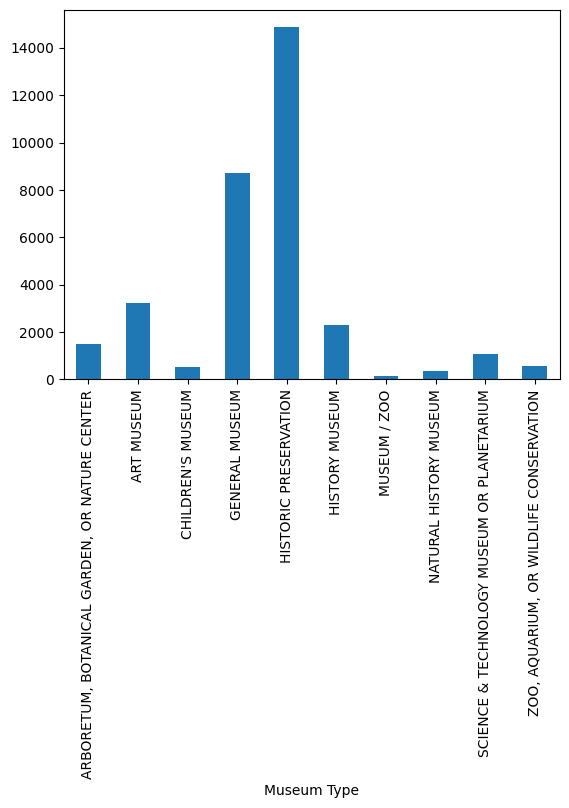

In [ ]:
# Bar chart of museum counts per museum type.
clean_copy.groupby('Museum Type').size().plot(kind='bar')

In [ ]:
# Focus subset: zoo/aquarium/wildlife records for targeted analysis.
zoo_aqua = clean_copy[clean_copy['Museum Type'].eq('ZOO, AQUARIUM, OR WILDLIFE CONSERVATION')].copy()

In [ ]:
# Preview the focused zoo/aquarium subset.
zoo_aqua


,Museum ID,Museum Name,Legal Name,Museum Type,Institution Name,City (Administrative Location),State (Administrative Location),City (Physical Location),State (Physical Location),Tax Period,Income,Revenue,Population (2008)
12,8.409500e+09,ALASKA SEALIFE CENTER,ALASKA SEALIFE CENTER,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,SEWARD,AK,SEWARD,AK,NaT,$nan,$nan,"687,455"
19,8.400200e+09,ALASKA ZOO,ALASKA ZOO,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,ANCHORAGE,AK,ANCHORAGE,AK,2013-12-01,"$3,310,088.00","$2,393,748.00","687,455"
109,8.400200e+09,OCEANSALASKA,OCEANSALASKA,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,KETCHIKAN,AK,KETCHIKAN,AK,2012-12-01,"$892,091.00","$534,898.00","687,455"
125,8.400200e+09,SEWARD ASSOCIATION FOR THE ADVANCEMENT OF MARI...,SEWARD ASSOCIATION FOR THE ADVANCEMENT OF MARI...,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,SEWARD,AK,SEWARD,AK,2013-09-01,"$9,601,562.00","$9,469,200.00","687,455"
205,8.400100e+09,ALABAMA WILDLIFE CENTER,ALABAMA WILDLIFE CENTER,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,PELHAM,AL,NaN,NaN,2013-12-01,"$463,192.00","$440,703.00","4,718,206"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32765,8.405500e+09,ZOOLOGICAL SOCIETY OF KEWAUNEE COUNTY,ZOOLOGICAL SOCIETY OF KEWAUNEE COUNTY INC,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,KEWAUNEE,WI,KEWAUNEE,WI,2014-09-01,$0.00,$0.00,"5,641,996"
32766,8.405501e+09,ZOOLOGICAL SOCIETY OF MILWAUKEE,ZOOLOGICAL SOCIETY OF MILWAUKEE COUNTY ENDOWME...,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,MILWAUKEE,WI,NaN,NaN,2014-09-01,"$4,286,798.00","$1,274,221.00","5,641,996"
32929,8.409500e+09,OGLEBAY'S GOOD ZOO,OGLEBAY'S GOOD ZOO,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,WHEELING,WV,WHEELING,WV,NaT,$nan,$nan,"1,840,310"
33131,8.405600e+09,MUSEUM OF NORTH AMERICAN WILDLIFE,MUSEUM OF NORTH AMERICAN WILDLIFE,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,CODY,WY,NaN,NaN,NaT,$nan,$nan,"546,043"


In [79]:
zoo = zoo_aqua['Museum Name'].str.contains('ZOO', case=False, na=False)
df_zoo = zoo_aqua[zoo]
df_zoo

,Museum ID,Museum Name,Legal Name,Museum Type,Institution Name,City (Administrative Location),State (Administrative Location),City (Physical Location),State (Physical Location),Tax Period,Income,Revenue,Population (2008)
19,8.400200e+09,ALASKA ZOO,ALASKA ZOO,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,ANCHORAGE,AK,ANCHORAGE,AK,2013-12-01,"$3,310,088.00","$2,393,748.00","687,455"
207,8.400100e+09,ALABAMA ZOOLOGICAL SOCIETY,ALABAMA ZOOLOGICAL SOCIETY,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,BIRMINGHAM,AL,NaN,NaN,2014-09-01,$0.00,$0.00,"4,718,206"
254,8.400100e+09,BIRMINGHAM ZOO,BIRMINGHAM ZOO INC,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,MOUNTAIN BRK,AL,NaN,NaN,2013-12-01,"$10,969,184.00","$8,932,428.00","4,718,206"
475,8.400100e+09,MOBILE ZOO,MOBILE ZOO,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,WILMER,AL,NaN,NaN,2013-12-01,"$54,423.00","$53,441.00","4,718,206"
478,8.400100e+09,MONTGOMERY AREA ZOOLOGICAL SOCIETY,MONTGOMERY AREA ZOOLOGICAL SOCIETY INC,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,MONTGOMERY,AL,MONTGOMERY,AL,2014-09-01,"$516,603.00","$502,005.00","4,718,206"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32720,8.405501e+09,WILDLIFE EXOTIC AND ZOO ANIMAL MEDICINE CLUB,WILDLIFE EXOTIC AND ZOO ANIMAL MEDICINE CLUB,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,MADISON,WI,NaN,NaN,NaT,$nan,$nan,"5,641,996"
32721,8.405500e+09,WILDWOOD ZOO - CITY OF MARSHFIELD,WILDWOOD PARK ZOOLOGICAL SOCIETY INC OF MARSHF...,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,MARSHFIELD,WI,MINOCQUA,WI,2014-07-01,"$54,734.00","$39,333.00","5,641,996"
32765,8.405500e+09,ZOOLOGICAL SOCIETY OF KEWAUNEE COUNTY,ZOOLOGICAL SOCIETY OF KEWAUNEE COUNTY INC,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,KEWAUNEE,WI,KEWAUNEE,WI,2014-09-01,$0.00,$0.00,"5,641,996"
32766,8.405501e+09,ZOOLOGICAL SOCIETY OF MILWAUKEE,ZOOLOGICAL SOCIETY OF MILWAUKEE COUNTY ENDOWME...,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,MILWAUKEE,WI,NaN,NaN,2014-09-01,"$4,286,798.00","$1,274,221.00","5,641,996"


In [80]:
aqua = zoo_aqua['Museum Name'].str.contains('AQUARIUM', case=False, na=False)
df_aqua = zoo_aqua[aqua]
df_aqua

,Museum ID,Museum Name,Legal Name,Museum Type,Institution Name,City (Administrative Location),State (Administrative Location),City (Physical Location),State (Physical Location),Tax Period,Income,Revenue,Population (2008)
1313,8.400400e+09,SONORAN SEA AQUARIUM,SONORAN SEA AQUARIUM,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,TUCSON,AZ,NaN,NaN,2010-12-01,$0.00,$0.00,"6,280,362"
1498,8.409500e+09,AQUARIUM OF THE BAY,AQUARIUM OF THE BAY,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,SAN FRANCISCO,CA,SAN FRANCISCO,CA,NaT,$nan,$nan,"36,604,337"
1499,8.400601e+09,AQUARIUM OF THE PACIFIC,AQUARIUM OF THE PACIFIC,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,LONG BEACH,CA,NaN,NaN,2013-12-01,"$38,286,191.00","$33,641,453.00","36,604,337"
1675,8.400601e+09,CABRILLO MARINE AQUARIUM,FRIENDS OF CABRILLO MARINE AQUARIUM,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,SAN PEDRO,CA,NaN,NaN,2014-06-01,"$1,109,599.00","$980,785.00","36,604,337"
1806,8.400602e+09,CENTRAL COAST AQUARIUM SOCIETY,CENTRAL COAST AQUARIUM SOCIETY,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,SHELL BEACH,CA,NaN,NaN,2012-12-01,$0.00,$0.00,"36,604,337"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30598,8.405101e+09,POTOMAC VALLEY AQUARIUM SOCIETY,POTOMAC VALLEY AQUARIUM SOCIETY INC GERALD HOF...,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,MERRIFIELD,VA,MERRIFIELD,VA,2013-12-01,$0.00,$0.00,"7,833,496"
31645,8.409500e+09,POINT DEFIANCE ZOO & AQUARIUM,POINT DEFIANCE ZOO & AQUARIUM,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,TACOMA,WA,TACOMA,WA,NaT,$nan,$nan,"6,562,231"
31663,8.405301e+09,PUGET SOUND AQUARIUM SOCIETY,PUGET SOUND AQUARIUM SOCIETY,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,DUPONT,WA,NaN,NaN,2014-07-01,$0.00,$0.00,"6,562,231"
31697,8.405300e+09,SEATTLE AQUARIUM,SEATTLE AQUARIUM SOCIETY-SEAS,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,SEATTLE,WA,NaN,NaN,2013-12-01,"$15,301,907.00","$14,467,857.00","6,562,231"


In [81]:
pd.merge(df_zoo, df_aqua, how='outer')

,Museum ID,Museum Name,Legal Name,Museum Type,Institution Name,City (Administrative Location),State (Administrative Location),City (Physical Location),State (Physical Location),Tax Period,Income,Revenue,Population (2008)
0,8.400100e+09,ALABAMA ZOOLOGICAL SOCIETY,ALABAMA ZOOLOGICAL SOCIETY,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,BIRMINGHAM,AL,NaN,NaN,2014-09-01,$0.00,$0.00,"4,718,206"
1,8.400100e+09,MONTGOMERY AREA ZOOLOGICAL SOCIETY,MONTGOMERY AREA ZOOLOGICAL SOCIETY INC,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,MONTGOMERY,AL,MONTGOMERY,AL,2014-09-01,"$516,603.00","$502,005.00","4,718,206"
2,8.400100e+09,MOBILE ZOO,MOBILE ZOO,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,WILMER,AL,NaN,NaN,2013-12-01,"$54,423.00","$53,441.00","4,718,206"
3,8.400100e+09,BIRMINGHAM ZOO,BIRMINGHAM ZOO INC,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,MOUNTAIN BRK,AL,NaN,NaN,2013-12-01,"$10,969,184.00","$8,932,428.00","4,718,206"
4,8.400200e+09,ALASKA ZOO,ALASKA ZOO,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,ANCHORAGE,AK,ANCHORAGE,AK,2013-12-01,"$3,310,088.00","$2,393,748.00","687,455"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
350,8.409502e+09,NAPLES ZOO AT CARIBBEAN GARDENS,NAPLES ZOO AT CARIBBEAN GARDENS,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,NAPLES,FL,NAPLES,FL,NaT,$nan,$nan,"18,527,305"
351,8.409502e+09,OKLAHOMA CITY ZOO & BOTANICAL GARDEN,OKLAHOMA CITY ZOO & BOTANICAL GARDEN,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,OKLAHOMA CITY,OK,OKLAHOMA CITY,OK,NaT,$nan,$nan,"3,668,976"
352,8.409502e+09,OREGON ZOO/HORTICULTURE,OREGON ZOO/HORTICULTURE,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,PORTLAND,OR,PORTLAND,OR,NaT,$nan,$nan,"3,768,748"
353,8.409502e+09,RIVERBANKS ZOO & BOTANICAL GARDEN,RIVERBANKS ZOO & BOTANICAL GARDEN,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,COLUMBIA,SC,NaN,NaN,NaT,$nan,$nan,"4,528,996"


In [ ]:
# State-level counts for the zoo/aquarium subset.
s_zoo_aqua = zoo_aqua.groupby('State (Administrative Location)').size().reset_index(name='Count').sort_values(by='Count', ascending=False)
s_zoo_aqua

,State (Administrative Location),Count
4,CA,47
9,FL,42
43,TX,39
34,NY,38
38,PA,21
48,WI,20
22,MI,19
35,OH,19
14,IL,17
24,MO,14


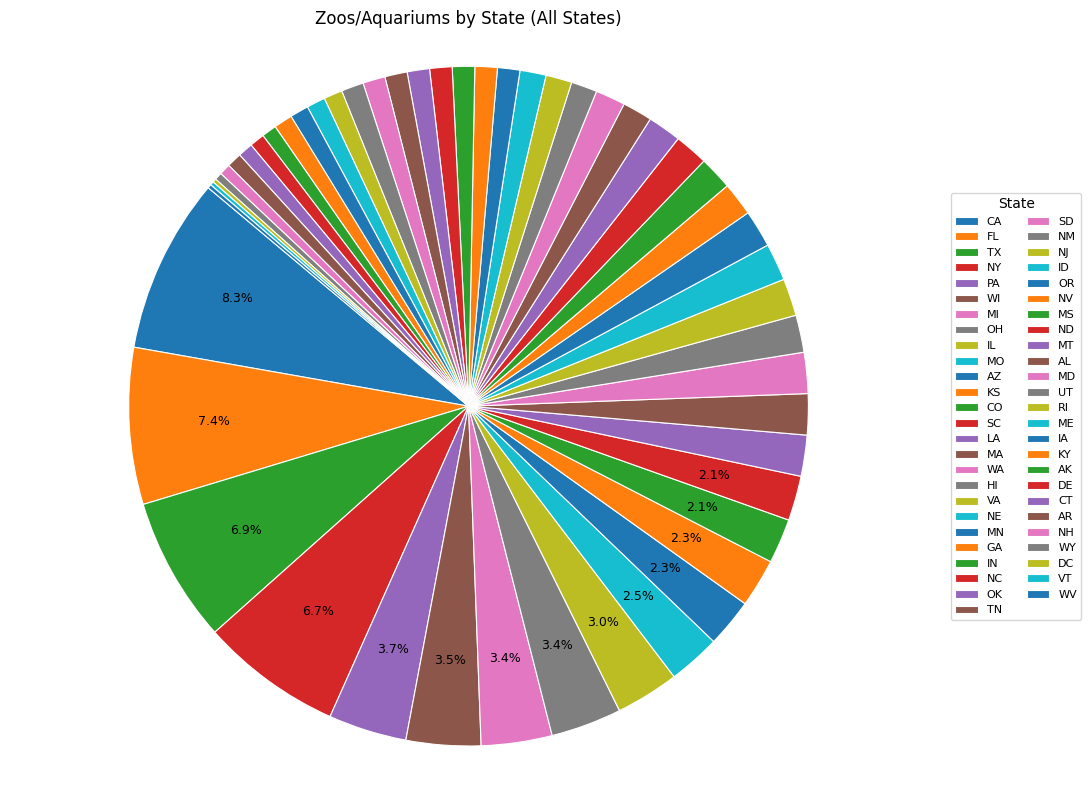

In [ ]:
import matplotlib.pyplot as plt

# Purpose: visualize zoo/aquarium counts by state as a pie chart.
# Notes: all states are shown; tiny percentage labels are hidden for readability.
pie_df = s_zoo_aqua[['State (Administrative Location)', 'Count']].copy()
pie_df = pie_df.sort_values('Count', ascending=False)

labels = pie_df['State (Administrative Location)']
values = pie_df['Count']

def pct_label(pct):
    # Keep chart readable: hide very tiny labels on slices.
    return f'{pct:.1f}%' if pct >= 2 else ''

fig, ax = plt.subplots(figsize=(11, 8))
wedges, _texts, autotexts = ax.pie(
    values,
    labels=None,
    autopct=pct_label,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 0.8},
    pctdistance=0.75,
)

for text in autotexts:
    text.set_fontsize(9)

ax.set_title('Zoos/Aquariums by State (All States)')
ax.axis('equal')

# Wider legend with multiple columns so all states are visible.
ax.legend(
    wedges,
    labels,
    title='State',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    ncol=2,
    fontsize=8,
    title_fontsize=10,
    frameon=True,
)

plt.tight_layout()
plt.show()

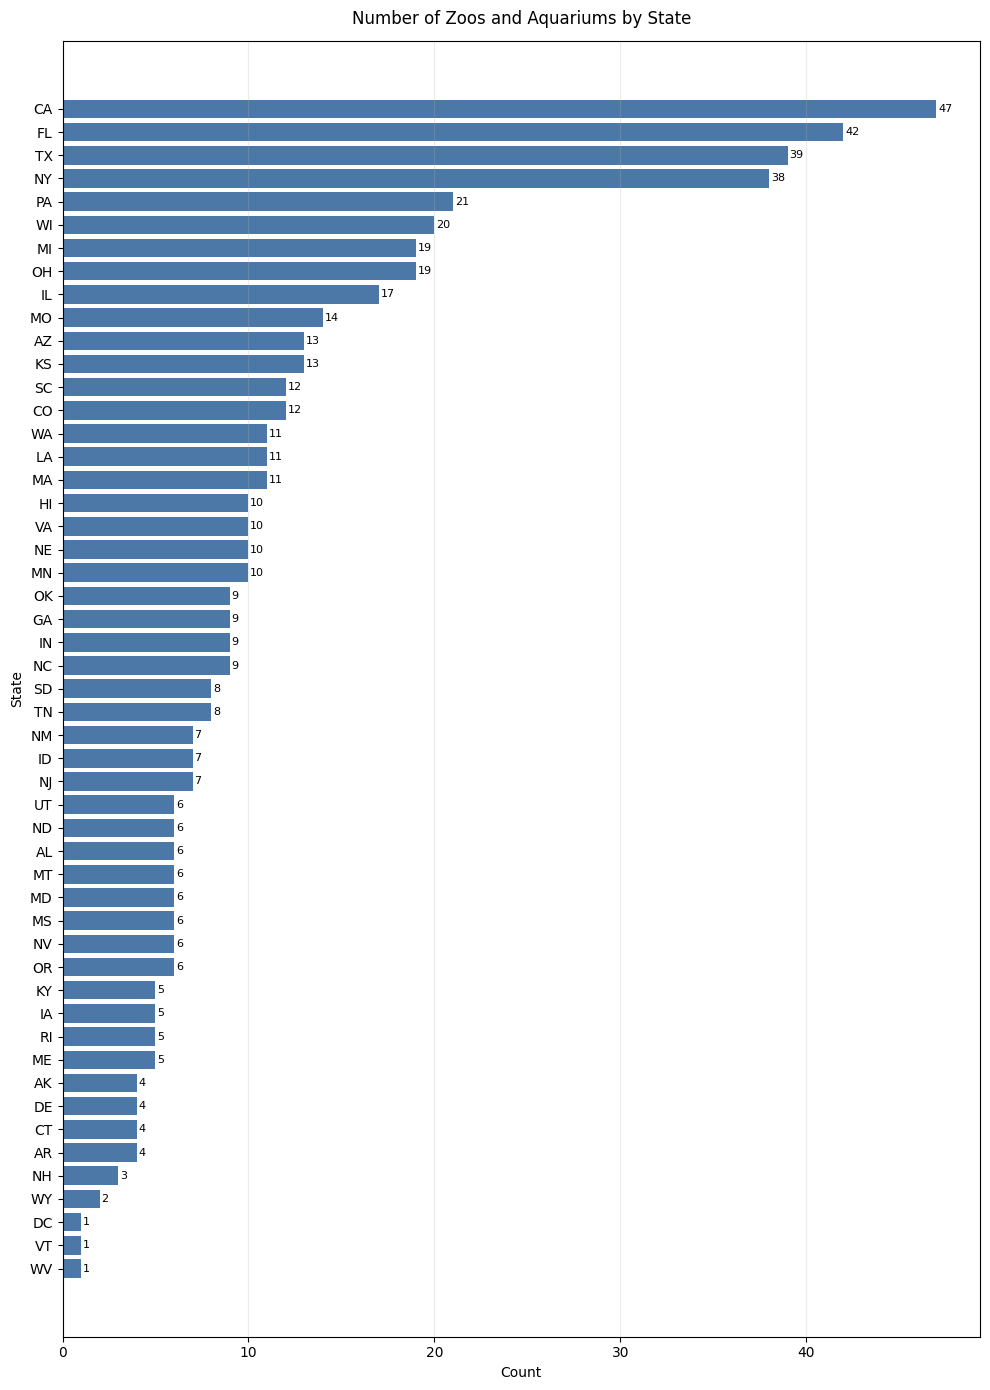

In [ ]:
import matplotlib.pyplot as plt

# Purpose: cleaner ranking view of zoo/aquarium counts by state.
# This chart is easier to compare than a pie when there are many categories.
state_counts = (
    s_zoo_aqua[['State (Administrative Location)', 'Count']]
    .dropna()
    .sort_values('Count', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(
    state_counts['State (Administrative Location)'],
    state_counts['Count'],
    color='#4C78A8'
)

ax.set_title('Number of Zoos and Aquariums by State', pad=12)
ax.set_xlabel('Count')
ax.set_ylabel('State')
ax.grid(axis='x', alpha=0.25)

for i, v in enumerate(state_counts['Count']):
    ax.text(v + 0.1, i, str(int(v)), va='center', fontsize=8)

plt.tight_layout()
plt.show()

Name-related columns: ['Museum Name', 'Legal Name', 'Institution Name']
Has Institution Name column? True
Has Museum Name column? True


,Museum Name
0,ALASKA AVIATION HERITAGE MUSEUM
1,ALASKA BOTANICAL GARDEN
2,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...
3,ALASKA EDUCATORS HISTORICAL SOCIETY
4,ALASKA HERITAGE MUSEUM
5,ALASKA HISTORICAL MUSEUM
6,ALASKA JEWISH MUSEUM
7,ALASKA LIGHTHOUSE ASSOCIATION
8,ALASKA MASONIC LIBRARY AND MUSEUM FOUNDATION
9,ALASKA MINING HALL OF FAME FOUNDATION


In [ ]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Purpose: interactive museum-type distribution by selected state.
state_col = 'State (Administrative Location)'
type_col = 'Museum Type'

# Build state x type counts.
state_type_counts = (
    clean_copy.groupby([state_col, type_col])
    .size()
    .reset_index(name='Count')
)

# All available states for dropdown control.
states = sorted(state_type_counts[state_col].dropna().unique())

# Keep one fixed category order across all states.
type_order = (
    state_type_counts.groupby(type_col)['Count']
    .sum()
    .sort_values(ascending=True)
    .index
)

def plot_state_museum_types(selected_state):
    # Filter to selected state, then reindex so every museum type is visible.
    state_data = state_type_counts[state_type_counts[state_col] == selected_state]
    state_series = (
        state_data.set_index(type_col)['Count']
        .reindex(type_order, fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(state_series.index, state_series.values)
    ax.set_title(f'Museum Type Distribution in {selected_state}')
    ax.set_xlabel('Count')
    ax.set_ylabel('Museum Type')
    ax.grid(axis='x', alpha=0.2)
    plt.tight_layout()
    plt.show()

# User control: select state to refresh chart.
state_dropdown = widgets.Dropdown(
    options=states,
    value=states[0],
    description='State:',
    layout=widgets.Layout(width='350px')
)

interactive_plot = widgets.interactive_output(
    plot_state_museum_types,
    {'selected_state': state_dropdown}
)

display(state_dropdown, interactive_plot)

Dropdown(description='State:', layout=Layout(width='350px'), options=('AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT'…

Output()

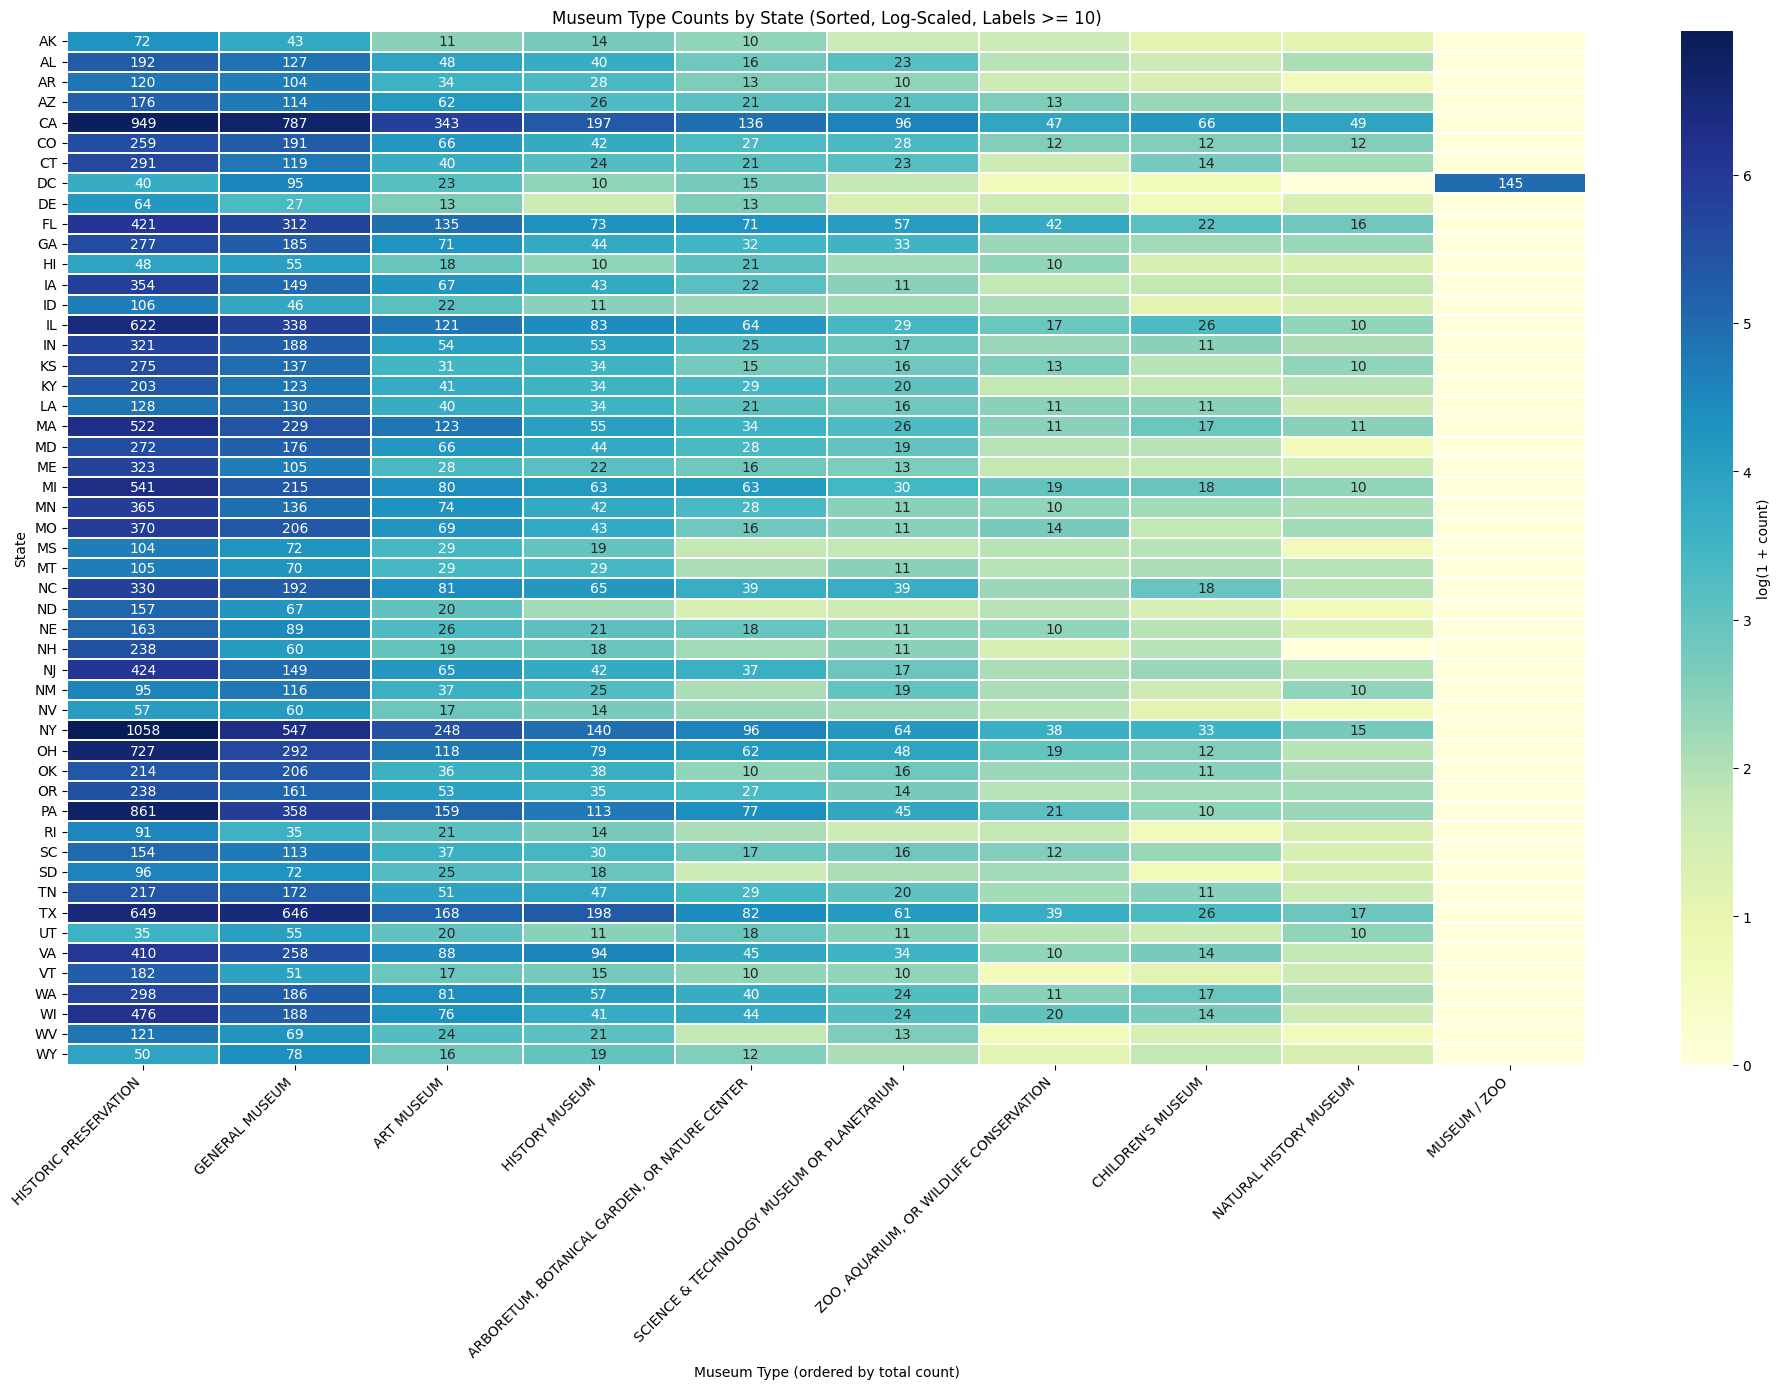

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Purpose: state x museum-type heatmap with improved readability.
heatmap_data = (
    clean_copy.groupby(['State (Administrative Location)', 'Museum Type'])
    .size()
    .unstack(fill_value=0)
)

# 1) Order columns by total frequency so most common museum types appear first.
ordered_cols = heatmap_data.sum(axis=0).sort_values(ascending=False).index
heatmap_data = heatmap_data[ordered_cols]

# 2) Use log scaling for color intensity while keeping raw counts as labels.
heatmap_log = np.log1p(heatmap_data)

# 3) Keep the chart readable: hide zeros and only annotate values >= 10.
annot_labels = heatmap_data.astype(str).mask(heatmap_data < 10, '')

plt.figure(figsize=(20, 14))
ax = sns.heatmap(
    heatmap_log,
    cmap='YlGnBu',
    linewidths=0.2,
    linecolor='white',
    annot=annot_labels,
    fmt='',
    cbar_kws={'label': 'log(1 + count)'}
)

plt.title('Museum Type Counts by State (Sorted, Log-Scaled, Labels >= 10)')
plt.xlabel('Museum Type (ordered by total count)')
plt.ylabel('State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Purpose: identify the museum(s) with maximum recorded revenue.
revenue_num = pd.to_numeric(
    clean_copy['Revenue'].astype(str).str.replace(r'[\$,]', '', regex=True),
    errors='coerce'
)

top_revenue_museums = clean_copy.assign(Revenue_num=revenue_num)
top_revenue_museums = top_revenue_museums[top_revenue_museums['Revenue_num'].notna()]

top_value = top_revenue_museums['Revenue_num'].max()

top_revenue_museums = (
    top_revenue_museums[top_revenue_museums['Revenue_num'].eq(top_value)]
    [['Museum Name', 'State (Administrative Location)', 'Revenue_num']]
    .drop_duplicates()
    .sort_values(['Museum Name', 'State (Administrative Location)'])
)

top_revenue_museums['Revenue'] = top_revenue_museums['Revenue_num'].map('${:,.0f}'.format)
top_revenue_museums[['Museum Name', 'State (Administrative Location)', 'Revenue']]

,Museum Name,State (Administrative Location),Revenue
12028,ARNOLD ARBORETUM OF HARVARD UNIVERSITY JAMAICA...,MA,"$5,840,349,457"
12048,AUTHUR M. SACKLER MUSEUM,MA,"$5,840,349,457"
12134,BUSCH-REISINGER MUSEUM,MA,"$5,840,349,457"
12166,CENTER FOR CONSERVATION AND TECHNICAL STUDIES,MA,"$5,840,349,457"
12209,COLLECTION OF SCIENTIFIC INSTRUMENTS,MA,"$5,840,349,457"
12293,FISHER MUSEUM,MA,"$5,840,349,457"
12296,FOGG ART MUSEUM,MA,"$5,840,349,457"
1090,FRED LAWRENCE WHIPPLE OBSERVATORY,AZ,"$5,840,349,457"
12324,GENERAL ARTEMAS WARD HOUSE,MA,"$5,840,349,457"
12366,HARVARD FOREST,MA,"$5,840,349,457"


In [88]:

revs = clean_copy['Revenue']
revs = pd.to_numeric(
    revs.astype(str).str.replace(r'[\$,]', '', regex=True),
    errors='coerce'
)
revs.describe().map('${:,.2f}'.format)


count           $22,290.00
mean        $20,976,047.06
std        $248,519,659.16
min         $-2,127,393.00
25%                  $0.00
50%              $3,307.00
75%            $167,696.00
max      $5,840,349,457.00
Name: Revenue, dtype: str

In [89]:
state_counts = clean_copy.groupby('State (Administrative Location)').size().reset_index(name='Count').sort_values(by='Count', ascending=False)
state_counts

,State (Administrative Location),Count
4,CA,2670
34,NY,2239
43,TX,1886
38,PA,1653
35,OH,1363
14,IL,1310
9,FL,1149
22,MI,1039
19,MA,1028
45,VA,958


In [90]:
museum_types = clean_copy.groupby('Museum Type').size().reset_index(name='Count').sort_values(by='Count', ascending=False)
museum_types

,Museum Type,Count
4,HISTORIC PRESERVATION,14861
3,GENERAL MUSEUM,8699
1,ART MUSEUM,3241
5,HISTORY MUSEUM,2284
0,"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",1484
8,SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,1081
9,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",564
2,CHILDREN'S MUSEUM,512
7,NATURAL HISTORY MUSEUM,346
6,MUSEUM / ZOO,145


In [91]:
museum_type_revenue = (
    clean_copy.assign(Revenue_num=revenue_num)
    .groupby('Museum Type')['Revenue_num']
    .sum()
    .reset_index()
    .sort_values(by='Revenue_num', ascending=False)
)
museum_type_revenue['Revenue'] = museum_type_revenue['Revenue_num'].map('${:,.2f}'.format)
museum_type_revenue[['Museum Type', 'Revenue']]

,Museum Type,Revenue
1,ART MUSEUM,"$185,852,033,185.00"
3,GENERAL MUSEUM,"$110,406,048,625.00"
0,"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER","$57,786,382,965.00"
8,SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,"$47,095,435,425.00"
4,HISTORIC PRESERVATION,"$25,204,822,787.00"
7,NATURAL HISTORY MUSEUM,"$20,092,106,106.00"
5,HISTORY MUSEUM,"$19,077,554,830.00"
9,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION","$1,601,211,797.00"
2,CHILDREN'S MUSEUM,"$440,493,179.00"
6,MUSEUM / ZOO,$0.00


Text(0, 0.5, 'Revenue (USD)')

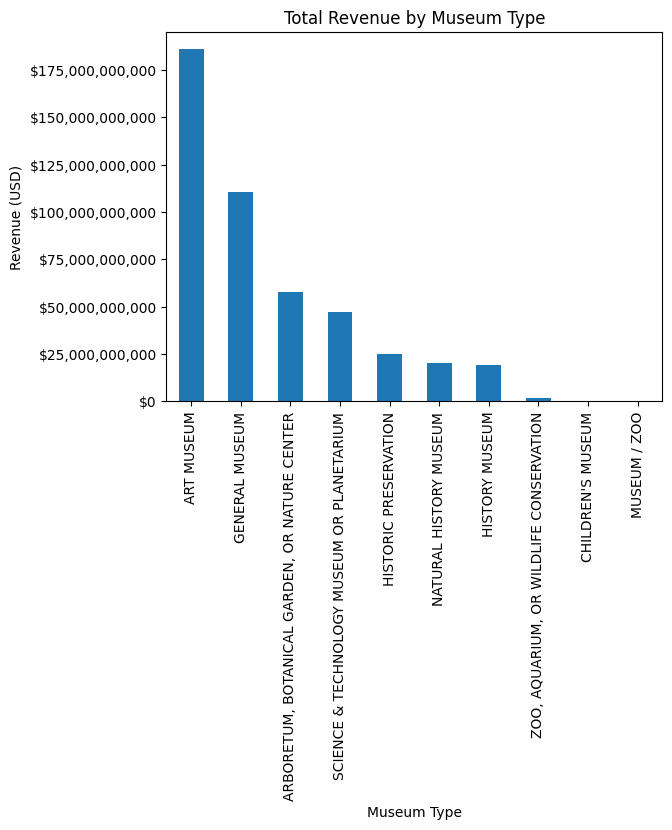

In [92]:
import matplotlib.ticker as mtick

ax = museum_type_revenue.plot(
    x='Museum Type',
    y='Revenue_num',
    kind='bar',
    legend=False,
    title='Total Revenue by Museum Type'
)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.set_ylabel('Revenue (USD)')

In [ ]:
# Purpose: descriptive statistics by museum type after filtering invalids and outliers.
stats_df = clean_copy.copy()

# Parse revenue/income from formatted strings into numeric values.
stats_df['Revenue_num'] = pd.to_numeric(
    stats_df['Revenue'].astype(str).str.replace(r'[\$,]', '', regex=True),
    errors='coerce'
)
stats_df['Income_num'] = pd.to_numeric(
    stats_df['Income'].astype(str).str.replace(r'[\$,]', '', regex=True),
    errors='coerce'
)

# Drop rows with NA or zero/non-positive values in either measure.
stats_df = stats_df.dropna(subset=['Revenue_num', 'Income_num'])
stats_df = stats_df[(stats_df['Revenue_num'] > 0) & (stats_df['Income_num'] > 0)]

# Drop outliers per museum type using the IQR rule for both revenue and income.
mask = pd.Series(True, index=stats_df.index)
for col in ['Revenue_num', 'Income_num']:
    q1 = stats_df.groupby('Museum Type')[col].transform(lambda s: s.quantile(0.25))
    q3 = stats_df.groupby('Museum Type')[col].transform(lambda s: s.quantile(0.75))
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask &= stats_df[col].between(lower, upper)

stats_no_outliers = stats_df[mask]

museum_type_describe = (
    stats_no_outliers.groupby('Museum Type')[['Revenue_num', 'Income_num']]
    .describe()
)

# Format key statistics for readability in USD.
usd_stats = ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
formatters = {
    ('Revenue_num', 'count'): '{:,.0f}'.format,
    ('Income_num', 'count'): '{:,.0f}'.format,
}
for metric in ['Revenue_num', 'Income_num']:
    for stat in usd_stats:
        formatters[(metric, stat)] = '${:,.2f}'.format

museum_type_describe.style.format(formatters)

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import ipywidgets as widgets
from IPython.display import display

state_col = 'State (Administrative Location)'
museum_col = 'Museum Name'
rev_col = 'Revenue'

# Convert revenue to numeric and keep only valid positive values.
rev_numeric = pd.to_numeric(
    clean_copy[rev_col].astype(str).str.replace(r'[\$,]', '', regex=True),
    errors='coerce'
)

state_revenue = clean_copy[[state_col, museum_col]].copy()
state_revenue['Revenue_num'] = rev_numeric

# Remove missing/blank state and museum names, and remove NA/zero revenue.
state_revenue[museum_col] = state_revenue[museum_col].astype(str).str.strip()
state_revenue[state_col] = state_revenue[state_col].astype(str).str.strip()
state_revenue = state_revenue[
    state_revenue[museum_col].ne('')
    & state_revenue[state_col].ne('')
    & state_revenue['Revenue_num'].notna()
    & state_revenue['Revenue_num'].gt(0)
]

# If duplicates exist, combine them so a museum appears once per state.
state_revenue = (
    state_revenue.groupby([state_col, museum_col], as_index=False)['Revenue_num']
    .sum()
)

states = sorted(state_revenue[state_col].unique())
max_rev = float(state_revenue['Revenue_num'].max())

def plot_state_revenue(selected_state, min_revenue):
    all_state_data = (
        state_revenue[state_revenue[state_col] == selected_state]
        .sort_values('Revenue_num', ascending=True)
        .reset_index(drop=True)
    )

    if all_state_data.empty:
        fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)
        ax.text(0.5, 0.5, 'No museums with revenue > 0 for this state.', ha='center', va='center')
        ax.axis('off')
        plt.show()
        return

    # Dynamic significance threshold: top quartile in selected state.
    state_q75 = all_state_data['Revenue_num'].quantile(0.75)
    threshold = max(float(min_revenue), float(state_q75))

    state_data = all_state_data[all_state_data['Revenue_num'] >= threshold]

    if state_data.empty:
        fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)
        ax.text(
            0.5,
            0.5,
            f'No museums meet threshold (${threshold:,.0f}) in {selected_state}.',
            ha='center',
            va='center'
        )
        ax.axis('off')
        plt.show()
        return

    # Keep the figure compact and remove top/bottom padding in the plotting area.
    fig_height = max(4, len(state_data) * 0.28)
    fig, ax = plt.subplots(figsize=(12, fig_height), constrained_layout=True)
    ax.barh(state_data[museum_col], state_data['Revenue_num'], color='#2E86AB')
    ax.set_title(
        f'Significant Museum Revenue in {selected_state} (threshold >= ${threshold:,.0f})',
        pad=6
    )
    ax.set_xlabel('Revenue (USD)')
    ax.set_ylabel('Museum')
    ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
    ax.grid(axis='x', alpha=0.2)

    # Remove internal whitespace at top/bottom of the bar area.
    ax.margins(y=0)
    ax.set_ylim(-0.5, len(state_data) - 0.5)

    plt.show()

state_dropdown = widgets.Dropdown(
    options=states,
    value=states[0],
    description='State:',
    layout=widgets.Layout(width='320px')
)

min_revenue_slider = widgets.FloatLogSlider(
    value=1e6,
    base=10,
    min=3,
    max=max(3, int(len(str(int(max_rev))) - 1)),
    step=0.1,
    description='Min rev:',
    readout_format=',.0f',
    layout=widgets.Layout(width='420px')
)

interactive_plot = widgets.interactive_output(
    plot_state_revenue,
    {
        'selected_state': state_dropdown,
        'min_revenue': min_revenue_slider,
    }
)

controls = widgets.HBox([state_dropdown, min_revenue_slider])
display(controls, interactive_plot)

Output()

In [95]:
#state_counts = clean_copy.groupby('State (Administrative Location)').size().reset_index(name='Count').sort_values(by='Count', ascending=False)
#state_counts["Count"] = state_counts["Count"].astype(int)
#state_pop = clean_copy.groupby('State (Administrative Location)').size().reset_index(name='Population (2008)').sort_values(by='State (Administrative Location)', ascending=True)
#state_pop["Population (2008)"] = state_pop["Population (2008)"].astype(int)
#per_capita = pd.merge(state_counts,state_pop, on="State (Administrative Location)", how="outer")
#state_pop
per_capita = clean_copy.groupby("State (Administrative Location)")["Population (2008)"].value_counts().reset_index(name="Count").sort_values(by="State (Administrative Location)", ascending=True)
per_capita["Count"] = per_capita["Count"].astype(int)
per_capita["Population (2008)"] = per_capita["Population (2008)"].astype(str).str.replace(r'[$\,]',"",regex=True)
per_capita["Population (2008)"] = per_capita["Population (2008)"].astype(int)
per_capita["per_capita"] = per_capita["Count"].div(per_capita["Population (2008)"])
per_capita.sort_values(by="per_capita", ascending=True)



,State (Administrative Location),Population (2008),Count,per_capita
9,FL,18527305,1149,0.000062
44,UT,2663029,170,0.000064
33,NV,2653630,174,0.000066
10,GA,9504843,668,0.000070
3,AZ,6280362,449,0.000071
4,CA,36604337,2670,0.000073
43,TX,24309039,1886,0.000078
27,NC,9309449,779,0.000084
25,MS,2947806,247,0.000084
40,SC,4528996,391,0.000086


In [96]:
revenue_num = pd.to_numeric(clean_copy['Revenue'].astype(str).str.replace(r'[\$,]', '', regex=True),errors='coerce')
museum_type_revenue = (clean_copy.assign(Revenue_num=revenue_num).groupby('Museum Type')['Revenue_num'].sum().reset_index().sort_values(by='Revenue_num', ascending=False))
museum_type_revenue['Revenue'] = museum_type_revenue['Revenue_num'].map('${:,.2f}'.format)
museum_type_revenue[['Museum Type', 'Revenue']]
museum_type_revenue

,Museum Type,Revenue_num,Revenue
1,ART MUSEUM,1.858520e+11,"$185,852,033,185.00"
3,GENERAL MUSEUM,1.104060e+11,"$110,406,048,625.00"
0,"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",5.778638e+10,"$57,786,382,965.00"
8,SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,4.709544e+10,"$47,095,435,425.00"
4,HISTORIC PRESERVATION,2.520482e+10,"$25,204,822,787.00"
7,NATURAL HISTORY MUSEUM,2.009211e+10,"$20,092,106,106.00"
5,HISTORY MUSEUM,1.907755e+10,"$19,077,554,830.00"
9,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",1.601212e+09,"$1,601,211,797.00"
2,CHILDREN'S MUSEUM,4.404932e+08,"$440,493,179.00"
6,MUSEUM / ZOO,0.000000e+00,$0.00
